### INVENTORY OPTIMIZATION

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Inventory Optimization
The objective of this section is to classify products based on their sales contribution and demand patterns, enabling better inventory planning and decision-making.

In [6]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.ipython', '.jupyter', '.python_history', '.streamlit', '.vscode', '.vscode-shared', '3D Objects', 'AppData', 'Application Data', 'Banking-EDA and data cleaning.ipynb', 'battery-report.html', 'Contacts', 'Cookies', 'Data Cleaning.ipynb', 'DataCoSupplyChain(EDA).ipynb', 'DataCoSupplyChain(inventory optimization).ipynb', 'DataCoSupplyChain_Cleaned(EDA).csv', 'DataCoSupplyChain_Cleaned.csv', 'Documents', 'Downloads', 'Favorites', 'firstprogram.py', 'firstprogram.py 2.txt', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{da216541-c0d9-11ee-a8cd-f48c506bf75f}.TM.blf', 'NTUSER.DAT{da216541-c0d9-11ee-a8cd-f48c506bf75f}.T

In [10]:
import pandas as pd

df = pd.read_csv(
    "DataCoSupplyChain_Cleaned.csv",
    parse_dates=["order_date_dateorders", "shipping_date_dateorders"]
)

In [11]:
df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,shipping_date_dateorders,shipping_mode,order_year,order_month,order_month_name,order_day,order_weekday,delivery_time,profit_margin,discount_percentage
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-02-03 22:56:00,Standard Class,2018,1,January,31,Wednesday,3,27.841342,4.000000
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,2018-01-18 12:27:00,Standard Class,2018,1,January,13,Saturday,5,-75.999999,5.000763
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,2018-01-17 12:06:00,Standard Class,2018,1,January,13,Saturday,4,-75.600305,5.501144
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,2018-01-16 11:45:00,Standard Class,2018,1,January,13,Saturday,3,6.974829,6.999237
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-01-15 11:24:00,Standard Class,2018,1,January,13,Saturday,2,40.948896,9.000763


In [12]:
print(df.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_image', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 'shipping_mode', 'order_year', 'order_mont

In [13]:
# Calculate Product Sales
abc = (
    df.groupby("product_name")["sales"]
      .sum()
      .reset_index()
)

abc = abc.sort_values(by="sales", ascending=False)

In [15]:
# Calculate Sales Percentage
abc["sales_percentage"] = (
    abc["sales"] / abc["sales"].sum()
) * 100

In [16]:
# Calculate Cumulative Percentage
abc["cumulative_percentage"] = abc["sales_percentage"].cumsum()

In [17]:
# Assign ABC Category
def abc_category(x):
    if x <= 70:
        return "A"
    elif x <= 90:
        return "B"
    else:
        return "C"

abc["ABC_Category"] = abc["cumulative_percentage"].apply(abc_category)

In [18]:
# View Results
abc.head(20)

,product_name,sales,sales_percentage,cumulative_percentage,ABC_Category
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,18.838395,18.838395,A
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,12.018962,30.857357,A
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,11.196018,42.053375,A
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,9.970530,52.023905,A
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,8.557354,60.581259,A
70,Pelican Sunstream 100 Kayak,3.099845e+06,8.426988,69.008247,A
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,7.861298,76.869545,B
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,7.853785,84.723330,B
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,3.450025,88.173355,B
18,Dell Laptop,6.630000e+05,1.802378,89.975733,B


In [19]:
# Count Products in Each Category
abc["ABC_Category"].value_counts()

ABC_Category
C    108
A      6
B      4
Name: count, dtype: int64

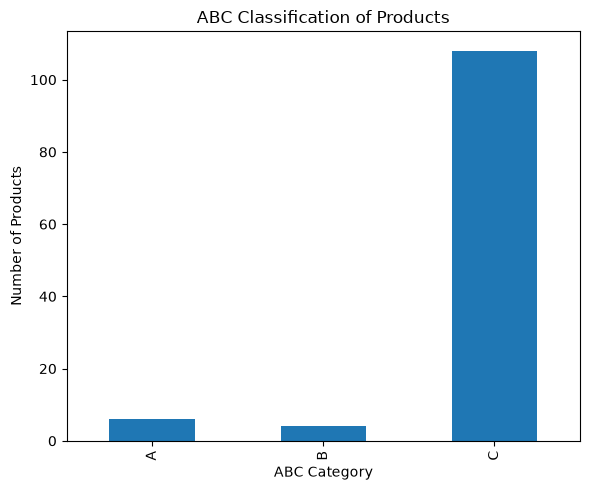

In [21]:
# Visualize ABC Categories
import matplotlib.pyplot as plt

abc["ABC_Category"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("ABC Classification of Products")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

### Business Insight
ABC Analysis categorizes products based on their contribution to total sales. Category **A** products generate the highest share of revenue and require close inventory monitoring and frequent replenishment. Category **B** products require moderate attention, while Category **C** products contribute less to revenue and can be managed with lower inventory priority.

In [22]:
# Display ABC Analysis Table
abc.head(15)

,product_name,sales,sales_percentage,cumulative_percentage,ABC_Category
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,18.838395,18.838395,A
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,12.018962,30.857357,A
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,11.196018,42.053375,A
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,9.970530,52.023905,A
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,8.557354,60.581259,A
70,Pelican Sunstream 100 Kayak,3.099845e+06,8.426988,69.008247,A
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,7.861298,76.869545,B
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,7.853785,84.723330,B
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,3.450025,88.173355,B
18,Dell Laptop,6.630000e+05,1.802378,89.975733,B


In [23]:
# Save ABC Analysis
abc.to_csv("ABC_Analysis.csv", index=False)

## Business Insight
ABC Analysis classifies products based on their contribution to total sales.
- Category A products contribute the highest revenue and require close inventory monitoring.
- Category B products contribute a moderate share of revenue and require periodic review.
- Category C products contribute the least revenue and can be managed with lower inventory priority.
  
This analysis helps optimize inventory investment and reduce stock-out risk for high-value products.

In [24]:
# Calculate Total Demand
demand = (
    df.groupby("product_name")["order_item_quantity"]
      .sum()
      .reset_index()
)

demand = demand.sort_values(
    by="order_item_quantity",
    ascending=False
)

In [25]:
# View Top Products
demand.head(10)

,product_name,order_item_quantity
71,Perfect Fitness Perfect Rip Deck,73698
59,Nike Men's Dri-FIT Victory Golf Polo,62956
67,O'Brien Men's Neoprene Life Vest,57803
61,Nike Men's Free 5.0+ Running Shoe,36680
102,Under Armour Girls' Toddler Spine Surge Runni,31735
56,Nike Men's CJ Elite 2 TD Football Cleat,22246
24,Field & Stream Sportsman 16 Gun Fire Safe,17325
70,Pelican Sunstream 100 Kayak,15500
21,Diamondback Women's Serene Classic Comfort Bi,13729
22,ENO Atlas Hammock Straps,998


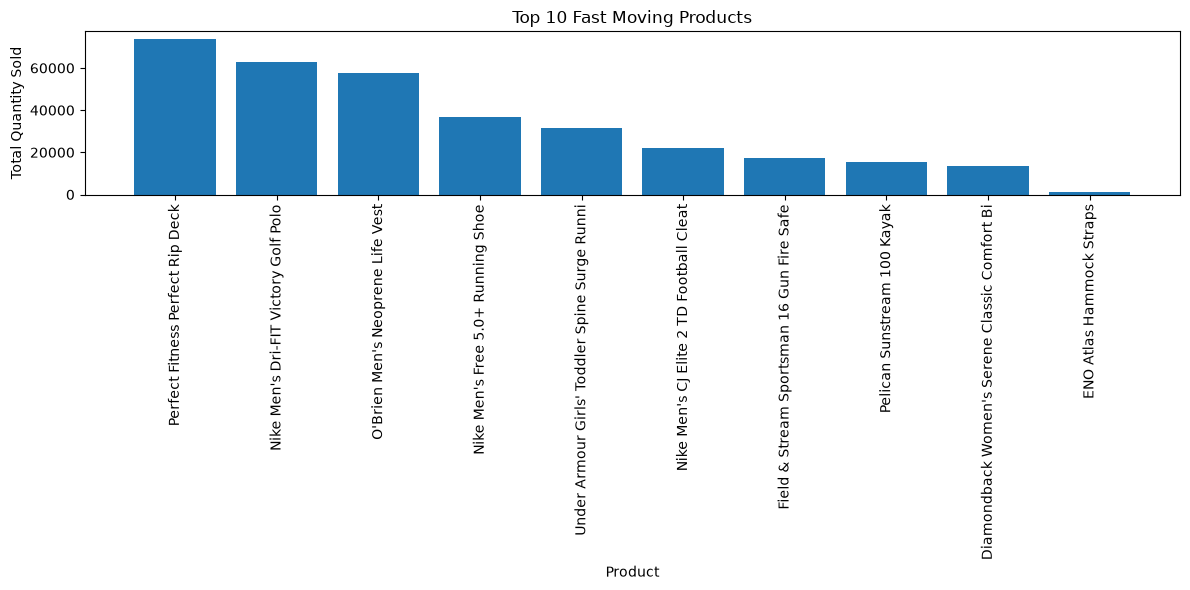

In [26]:
# Plot Top 10 Fast-Moving Products
import matplotlib.pyplot as plt

top10 = demand.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["product_name"],
    top10["order_item_quantity"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Fast Moving Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

### Business Insight

Products with the highest sales volume are fast-moving items and require frequent replenishment to avoid stock-outs. Monitoring these products helps improve inventory availability and customer satisfaction.

In [27]:
# Create Product Movement Categories
# Calculate demand quartiles
q1 = demand["order_item_quantity"].quantile(0.25)
q3 = demand["order_item_quantity"].quantile(0.75)

def movement_category(qty):
    if qty >= q3:
        return "Fast Moving"
    elif qty >= q1:
        return "Medium Moving"
    else:
        return "Slow Moving"

demand["Movement_Category"] = demand["order_item_quantity"].apply(movement_category)

In [28]:
# Check Category Counts
demand["Movement_Category"].value_counts()

Movement_Category
Medium Moving    58
Fast Moving      30
Slow Moving      30
Name: count, dtype: int64

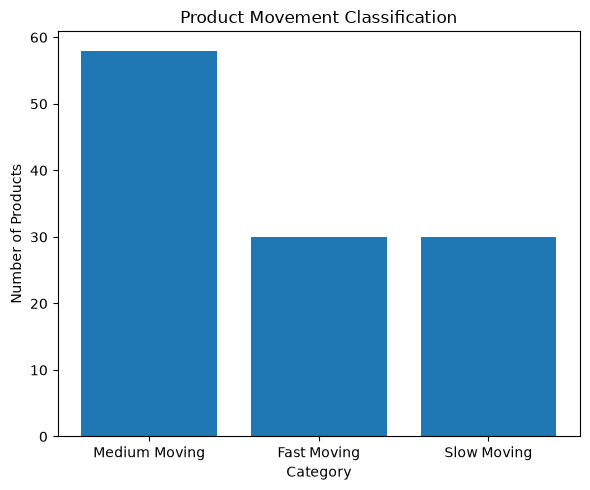

In [29]:
# Visualization
import matplotlib.pyplot as plt

movement = demand["Movement_Category"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(movement.index, movement.values)
plt.title("Product Movement Classification")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

### Business Insight
Fast-moving products require frequent replenishment to avoid stock-outs, while slow-moving products should be monitored carefully to reduce excess inventory and storage costs. This classification supports better inventory planning and warehouse utilization.

In [30]:
# Inventory Value Analysis
# This estimates the total inventory value represented by each product based on sales.

inventory_value = (
    df.groupby("product_name")
      .agg(
          Total_Sales=("sales", "sum"),
          Quantity=("order_item_quantity", "sum")
      )
      .reset_index()
)

inventory_value["Average_Selling_Price"] = (
    inventory_value["Total_Sales"] /
    inventory_value["Quantity"]
)

inventory_value.head()

,product_name,Total_Sales,Quantity,Average_Selling_Price
0,Adult dog supplies,41524.800753,492,84.400002
1,Baby sweater,12229.560379,207,59.080002
2,Bag Boy Beverage Holder,21116.549776,845,24.990000
3,Bag Boy M330 Push Cart,16637.919929,208,79.990000
4,Bowflex SelectTech 1090 Dumbbells,5999.899902,10,599.989990


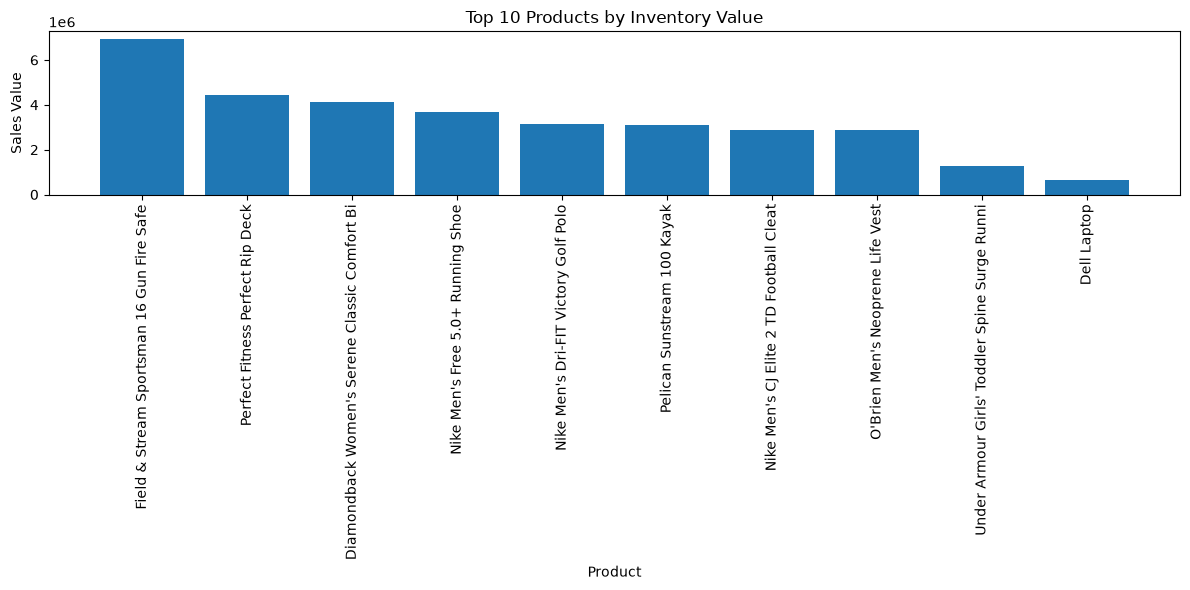

In [31]:
# Top 10 Products by Inventory Value
top_inventory = inventory_value.sort_values(
    by="Total_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.bar(
    top_inventory["product_name"],
    top_inventory["Total_Sales"]
)
plt.xticks(rotation=90)
plt.title("Top 10 Products by Inventory Value")
plt.xlabel("Product")
plt.ylabel("Sales Value")
plt.tight_layout()
plt.show()

In [32]:
# Average daily demand per product
safety_stock = (
    df.groupby("product_name")
      .agg(
          avg_daily_demand=("order_item_quantity", "mean"),
          demand_std=("order_item_quantity", "std"),
          avg_lead_time=("days_for_shipment_scheduled", "mean")
      )
      .reset_index()
)

# Replace NaN standard deviation with 0
safety_stock["demand_std"] = safety_stock["demand_std"].fillna(0)

# Safety Stock Formula
Z = 1.65

safety_stock["Safety_Stock"] = (
    Z *
    safety_stock["demand_std"] *
    np.sqrt(safety_stock["avg_lead_time"])
).round()

safety_stock.head()

,product_name,avg_daily_demand,demand_std,avg_lead_time,Safety_Stock
0,Adult dog supplies,1.000000,0.000000,2.678862,0.0
1,Baby sweater,1.000000,0.000000,2.705314,0.0
2,Bag Boy Beverage Holder,3.028674,1.449101,3.043011,4.0
3,Bag Boy M330 Push Cart,3.014493,1.289012,2.898551,4.0
4,Bowflex SelectTech 1090 Dumbbells,1.000000,0.000000,2.700000,0.0


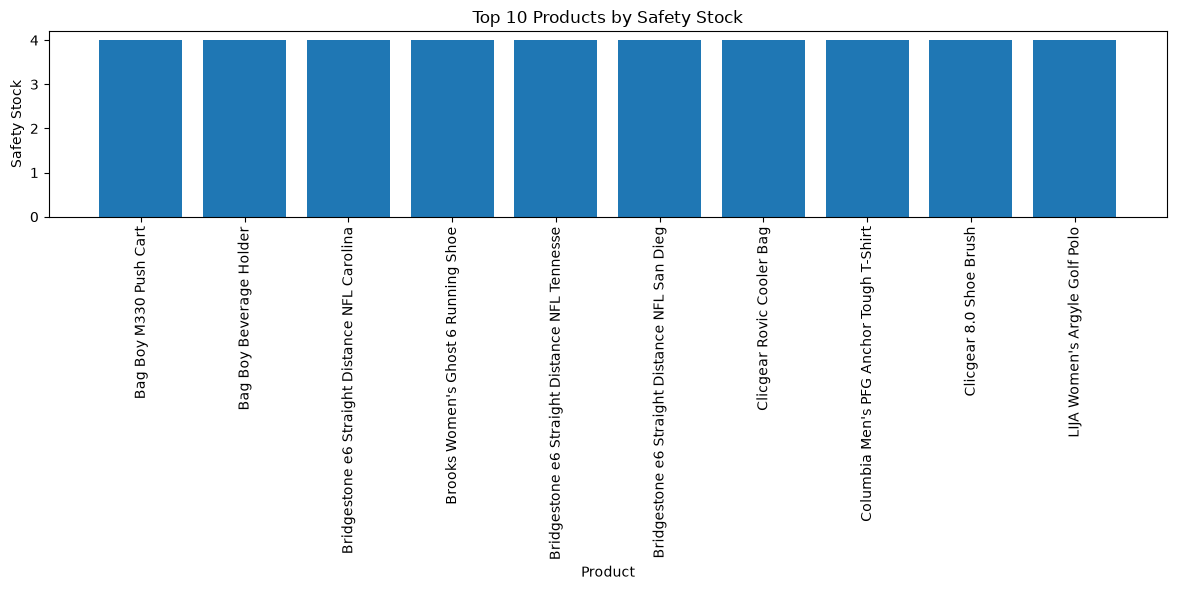

In [33]:
# Visualization
top_ss = safety_stock.sort_values(
    by="Safety_Stock",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_ss["product_name"],
    top_ss["Safety_Stock"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Products by Safety Stock")
plt.xlabel("Product")
plt.ylabel("Safety Stock")

plt.tight_layout()
plt.show()

In [34]:
# Reorder Point (ROP)
# ROP=(Average Daily Demand×Lead Time)+Safety Stock
safety_stock["Reorder_Point"] = (
    safety_stock["avg_daily_demand"] *
    safety_stock["avg_lead_time"]
) + safety_stock["Safety_Stock"]

safety_stock.head()

,product_name,avg_daily_demand,demand_std,avg_lead_time,Safety_Stock,Reorder_Point
0,Adult dog supplies,1.000000,0.000000,2.678862,0.0,2.678862
1,Baby sweater,1.000000,0.000000,2.705314,0.0,2.705314
2,Bag Boy Beverage Holder,3.028674,1.449101,3.043011,4.0,13.216287
3,Bag Boy M330 Push Cart,3.014493,1.289012,2.898551,4.0,12.737660
4,Bowflex SelectTech 1090 Dumbbells,1.000000,0.000000,2.700000,0.0,2.700000


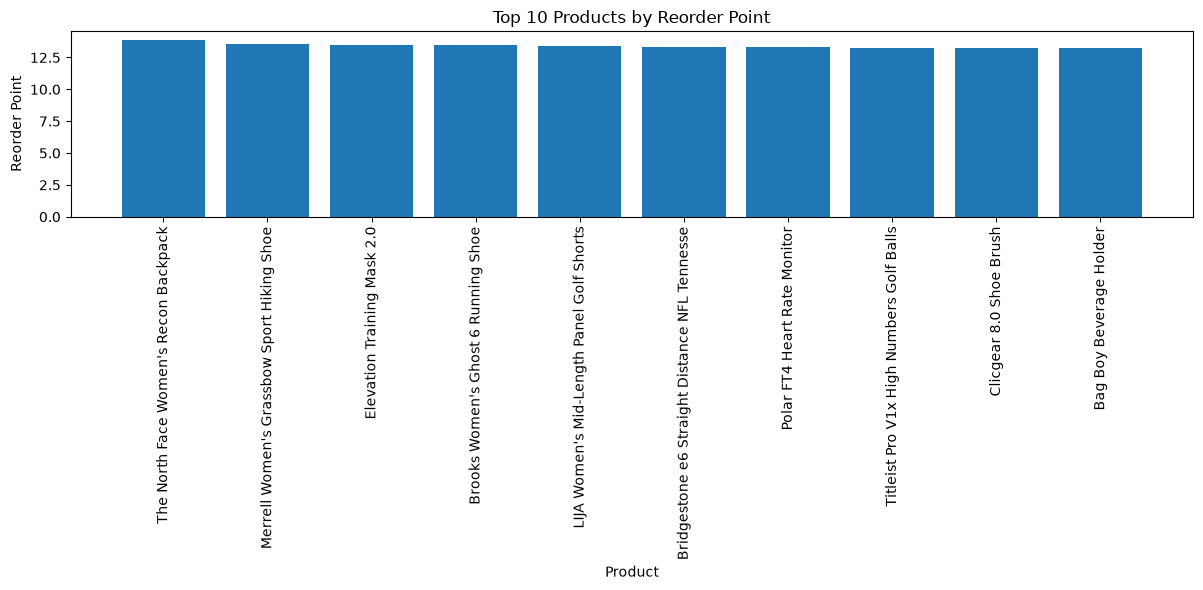

In [35]:
top_rop = safety_stock.sort_values(
    by="Reorder_Point",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_rop["product_name"],
    top_rop["Reorder_Point"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Products by Reorder Point")
plt.xlabel("Product")
plt.ylabel("Reorder Point")

plt.tight_layout()
plt.show()

In [40]:
# Create the EOQ table
eoq = (
    df.groupby("product_name")
      .agg(
          Annual_Demand=("order_item_quantity", "sum"),
          Product_Price=("product_price", "mean")
      )
      .reset_index()
)

eoq.head()

,product_name,Annual_Demand,Product_Price
0,Adult dog supplies,492,84.400002
1,Baby sweater,207,59.080002
2,Bag Boy Beverage Holder,845,24.990000
3,Bag Boy M330 Push Cart,208,79.989998
4,Bowflex SelectTech 1090 Dumbbells,10,599.989990


In [42]:
ordering_cost = 50
holding_cost_rate = 0.20

eoq["Holding_Cost"] = (
    eoq["Product_Price"] * holding_cost_rate
)

In [43]:
# Calculate EOQ
eoq["EOQ"] = np.sqrt(
    (2 * eoq["Annual_Demand"] * ordering_cost)
    / eoq["Holding_Cost"]
)

eoq["EOQ"] = eoq["EOQ"].round(0)

In [44]:
# output
eoq.head()

,product_name,Annual_Demand,Product_Price,Holding_Cost,EOQ
0,Adult dog supplies,492,84.400002,16.880000,54.0
1,Baby sweater,207,59.080002,11.816000,42.0
2,Bag Boy Beverage Holder,845,24.990000,4.998000,130.0
3,Bag Boy M330 Push Cart,208,79.989998,15.998000,36.0
4,Bowflex SelectTech 1090 Dumbbells,10,599.989990,119.997998,3.0


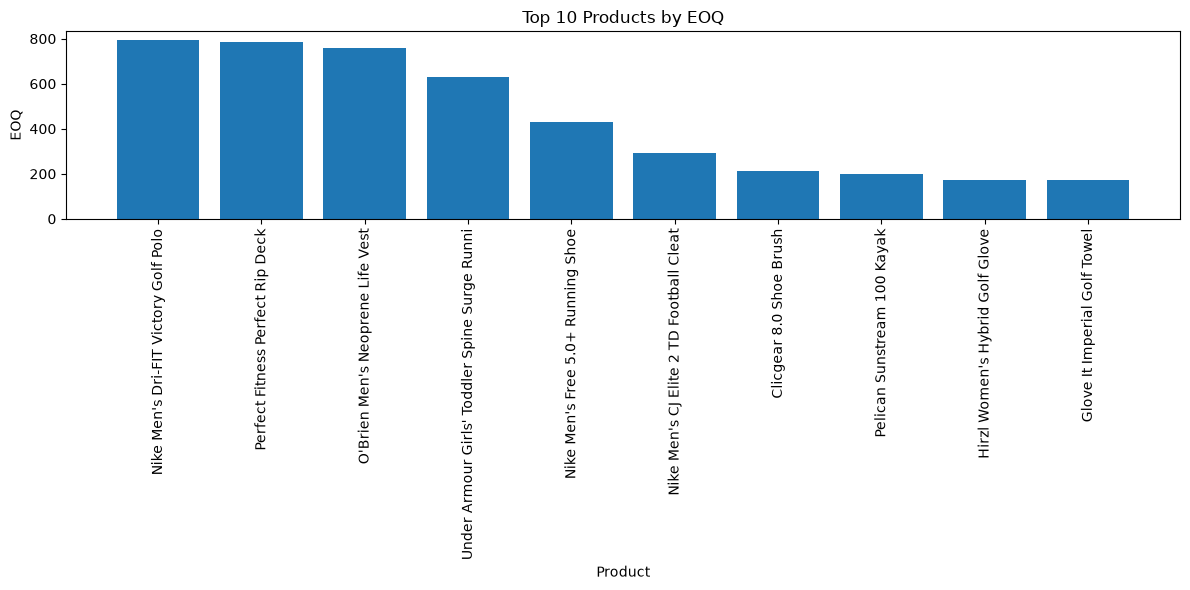

In [45]:
# Visualize the Top 10 EOQ
import matplotlib.pyplot as plt

top10 = eoq.sort_values(
    by="EOQ",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["product_name"],
    top10["EOQ"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Products by EOQ")
plt.xlabel("Product")
plt.ylabel("EOQ")

plt.tight_layout()
plt.show()

## Business Insight
Economic Order Quantity (EOQ) estimates the optimal order quantity that minimizes the combined ordering and inventory holding costs.Since the dataset does not contain actual ordering and holding costs standard assumptions were used for demonstration purposes.

In [46]:
## Export Cleaned Dataset
safety_stock.to_csv(
    "Inventory_Optimization_Results.csv",
    index=False
)